In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from heston.closed import heston_closed_price
from heston.tree import HestonTreeFast

from neural_network.payoff import Call, Put
from neural_network.config import ModelConfig, HestonParams
from neural_network.trainer import HestonTrainer

In [2]:
exercise_type = 'american'
option_type = 'put'
payoff = Put() if option_type == 'put' else Call()

In [3]:
S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

## Neural network vs Tree

In [4]:
S_max = 3 * S0
V_max = 0.2

params = HestonParams(
    S0=S0, v0=v0, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho, T=T, K=K,
    S_max=S_max, V_max=V_max
)

model_config = ModelConfig(
    input_size=3,
    hidden_sizes=[64, 128, 128, 64],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=1e-3
)

loss_weights = {
    'pde': 10.0,
    'payoff': 0.5,
    'S_min': 1.0,
    'S_max': 1.0,
    'V_min': 0.5,
    'V_max': 0.5,
}

heston_trainer = HestonTrainer(model_config=model_config, heston_params=params, payoff=payoff, exercise_type=exercise_type, loss_weights=loss_weights, seed=42)

In [5]:
heston_trainer.train(batch_size=1024, epochs=10000, tol=1e-6)

Iteration 0, Loss: 2.473776340484619
Iteration 100, Loss: 0.0019138155039399862
Iteration 200, Loss: 0.0006555065629072487
Iteration 300, Loss: 0.0003848189371638
Iteration 400, Loss: 0.0003601741627790034
Iteration 500, Loss: 0.00029765249928459525
Iteration 600, Loss: 0.0002528876648284495
Iteration 700, Loss: 0.00027699777274392545
Iteration 800, Loss: 0.00020811628201045096
Iteration 900, Loss: 0.00019743511802516878
Iteration 1000, Loss: 0.0002672119007911533
Iteration 1100, Loss: 0.0001691628131084144
Iteration 1200, Loss: 0.0001650678168516606
Iteration 1300, Loss: 0.00014923849084880203
Iteration 1400, Loss: 0.00016190006863325834
Iteration 1500, Loss: 0.00012865070311818272
Iteration 1600, Loss: 0.000142617616802454
Iteration 1700, Loss: 0.00012919669097755104
Early stopping at epoch 1728


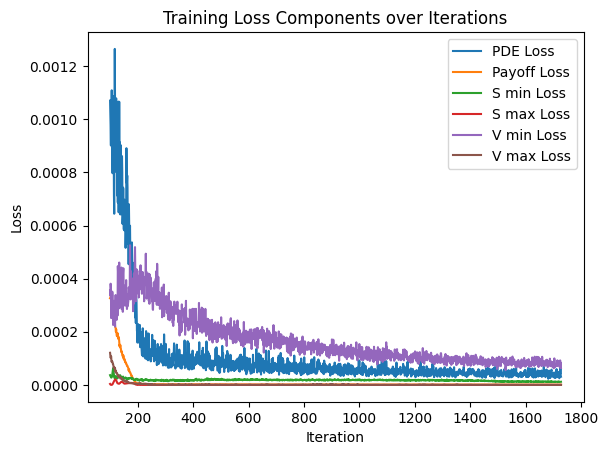

In [6]:
heston_trainer.plot_losses_detailed(start_epoch=100)

In [7]:
# Heston Tree
n = 100
mv = 3 * n
mz = 6 * n
tree = HestonTreeFast(n=100, mz=mz, mv=mv, K=K, T=T, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho)
tree.build_tree(0.01, V_max, 0.01, S_max, option_type=option_type, exercise_type=exercise_type)

In [8]:
# grid resolution
num_S = 80
num_V = 80

Ss = np.linspace(0.01, S_max, num_S)
Vs = np.linspace(0.01, V_max, num_V)
t = 0

nn_prices = np.zeros((num_V, num_S))
ht_prices = np.zeros((num_V, num_S))

for i, v_val in enumerate(Vs):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = heston_trainer.predict(t, s_val, v_val).item()
        ht_prices[i, j] = tree.price(v_val, s_val, int(t * n - 0.5))

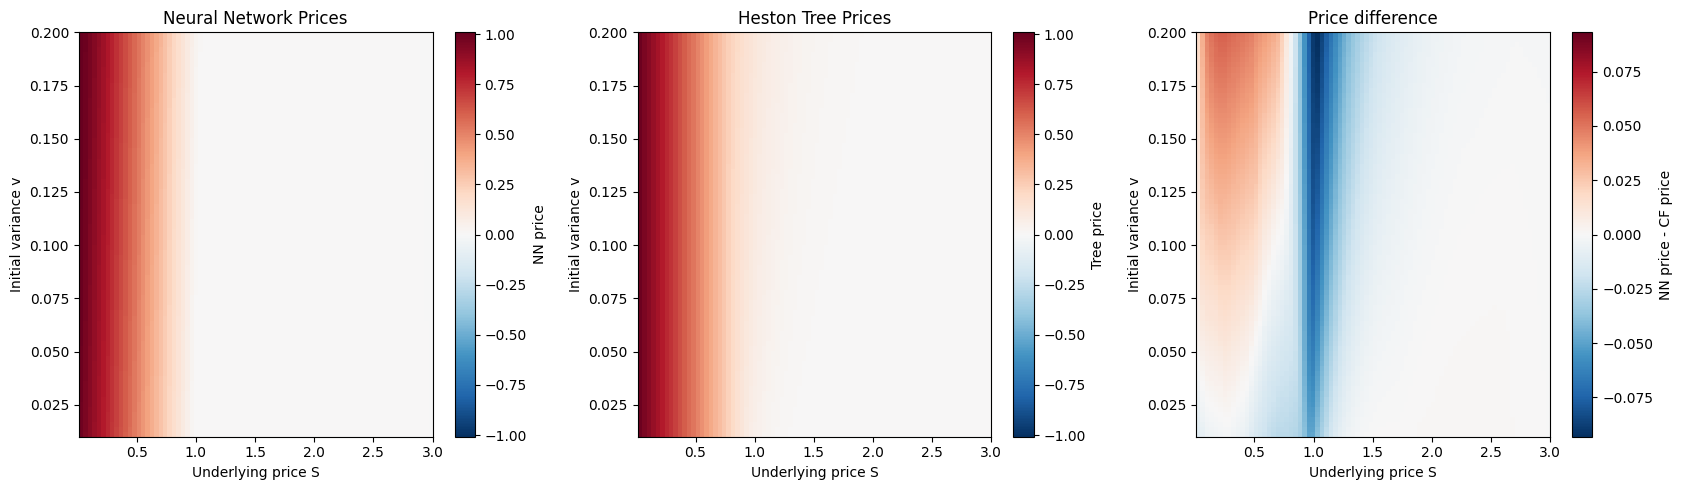

In [9]:
plt.figure(figsize=(17, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices).max()
vmin = -vmax
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Neural Network Prices')

plt.subplot(1, 3, 2)
im2 = plt.imshow(ht_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, label='Tree price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Heston Tree Prices')

plt.subplot(1, 3, 3)
diff = nn_prices - ht_prices
# diff = (nn_prices - ht_prices) / np.maximum(np.abs(ht_prices), 1e-4)  # Relative difference, avoid division by zero
# max_rel = 0.3
# diff = np.clip(diff, -max_rel, max_rel)  # Clip extreme values for better visualization
vmax = np.abs(diff).max()
vmin = -vmax
im3 = plt.imshow(diff, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im3, label='NN price - CF price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Price difference')
plt.tight_layout()
plt.show()

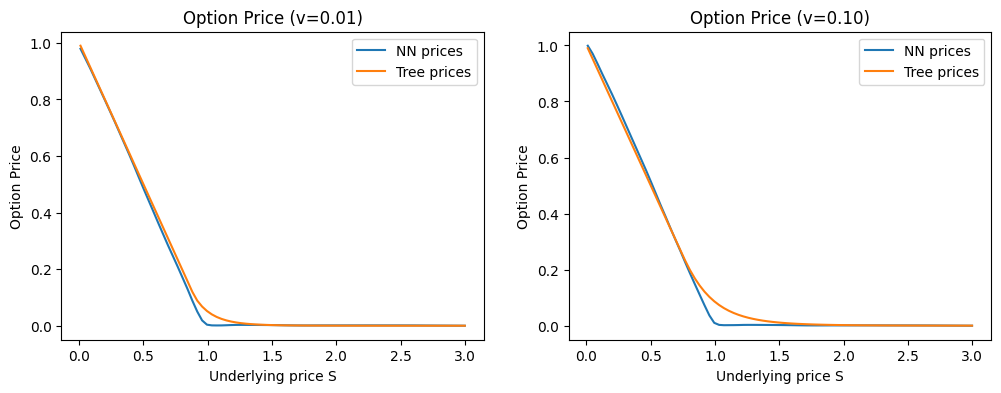

In [10]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
v_ind = 0
plt.plot(Ss, nn_prices[v_ind, :], label='NN prices')
plt.plot(Ss, ht_prices[v_ind, :], label='Tree prices')
plt.xlabel('Underlying price S')
plt.ylabel('Option Price')
plt.title(f'Option Price (v={Vs[v_ind]:.2f})')
plt.legend()

plt.subplot(1, 2, 2)
v_ind = 37
plt.plot(Ss, nn_prices[v_ind, :], label='NN prices')
plt.plot(Ss, ht_prices[v_ind, :], label='Tree prices')
plt.xlabel('Underlying price S')
plt.ylabel('Option Price')
plt.title(f'Option Price (v={Vs[v_ind]:.2f})')
plt.legend()

plt.show()

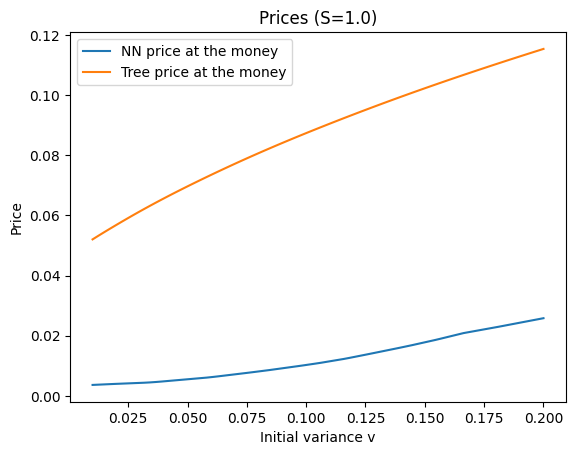

In [11]:
# Relative error at the money

S_ind = 26
# rel_err_atm = np.abs(nn_prices[:, S_ind] - ht_prices[:, S_ind]) / np.maximum(np.abs(ht_prices[:, S_ind]), 1e-4)
# plt.plot(Vs, rel_err_atm, label='Relative error at the money')
plt.plot(Vs, nn_prices[:, S_ind], label='NN price at the money')
plt.plot(Vs, ht_prices[:, S_ind], label='Tree price at the money')
plt.xlabel('Initial variance v')
plt.ylabel('Price')
plt.title(f'Prices (S={Ss[S_ind]:.1f})')
plt.legend()
plt.show()